In [ ]:
import os
import pandas as pd
import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision import models, transforms
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

base_path = "/content/drive/MyDrive/Project Agri/Dataset"

field1_path = os.path.join(base_path, "Field Images/FieldImages-1")
field2_path = os.path.join(base_path, "Field Images/FieldImages-2")
lab_path    = os.path.join(base_path, "Lab Images")

Mounted at /content/drive


In [ ]:
csv_path = os.path.join(field1_path, "Corn-Annotations.csv")
df1 = pd.read_csv(csv_path)

disease_cols = [
    "GLS","NCLB","PLS","CR","SR",
    "NoFoliarSymptoms","Other","UnidentifiedDisease"
]

df1["label_count"] = df1[disease_cols].sum(axis=1)
df1 = df1[df1["label_count"] == 1]

def get_label(row):
    for col in disease_cols:
        if row[col] == 1:
            return col

df1["label"] = df1.apply(get_label, axis=1)

image_folder = os.path.join(field1_path, "leaf_images")
df1["image_path"] = df1["filePath"].apply(lambda x: os.path.join(image_folder, x))

df1["source"] = "field"
df1 = df1[["image_path", "label", "source"]]

In [ ]:
data_field2 = []

for label in os.listdir(field2_path):
    class_path = os.path.join(field2_path, label)

    if os.path.isdir(class_path):
        for img in os.listdir(class_path):
            data_field2.append([
                os.path.join(class_path, img),
                label.upper(),
                "field"
            ])

df2 = pd.DataFrame(data_field2, columns=["image_path","label","source"])

In [ ]:
data_lab = []

for label in os.listdir(lab_path):
    class_path = os.path.join(lab_path, label)

    if os.path.isdir(class_path):
        for img in os.listdir(class_path):
            data_lab.append([
                os.path.join(class_path, img),
                label,
                "lab"
            ])

df3 = pd.DataFrame(data_lab, columns=["image_path","label","source"])

In [ ]:
label_map = {

    # Gray Leaf Spot
    "GLS": "Gray_Leaf_Spot",
    "Corn_Cercospora_leaf_spot_Gray_leaf_spot": "Gray_Leaf_Spot",

    # Northern Leaf Blight
    "NCLB": "Northern_Leaf_Blight",
    "NLB": "Northern_Leaf_Blight",
    "NLS": "Northern_Leaf_Blight",
    "Corn_Northern_Leaf_Blight": "Northern_Leaf_Blight",

    # Common Rust
    "CR": "Common_Rust",
    "Corn_Common_rust": "Common_Rust",

    # Healthy
    "NoFoliarSymptoms": "Healthy",
    "Corn_healthy": "Healthy",

    # Others
    "PLS": "Phaeosphaeria_Leaf_Spot",
    "SR": "Southern_Rust"
}

def standardise(x):
    x = str(x).strip()
    x = x.replace("___", "_").replace(" ", "_")
    return label_map.get(x, x)

df1["label"] = df1["label"].apply(standardise)
df2["label"] = df2["label"].apply(standardise)
df3["label"] = df3["label"].apply(standardise)

In [ ]:
df_all = pd.concat([df1, df2, df3], ignore_index=True)

print(df_all["label"].value_counts())

label
Northern_Leaf_Blight       2173
Gray_Leaf_Spot             1666
Healthy                    1394
Common_Rust                1299
UnidentifiedDisease         150
Phaeosphaeria_Leaf_Spot     149
Other                        49
Southern_Rust                 7
Name: count, dtype: int64


In [ ]:
keep_classes = [
    "Northern_Leaf_Blight",
    "Gray_Leaf_Spot",
    "Healthy",
    "Common_Rust"
]

df_all = df_all[df_all["label"].isin(keep_classes)].reset_index(drop=True)

print(df_all["label"].value_counts())

label
Northern_Leaf_Blight    2173
Gray_Leaf_Spot          1666
Healthy                 1394
Common_Rust             1299
Name: count, dtype: int64


In [ ]:
labels = sorted(df_all["label"].unique())

label_to_idx = {label: i for i, label in enumerate(labels)}
idx_to_label = {i: label for label, i in label_to_idx.items()}

df_all["label_idx"] = df_all["label"].map(label_to_idx)

num_classes = len(labels)
print("Classes:", labels)
print("Num classes:", num_classes)

Classes: ['Common_Rust', 'Gray_Leaf_Spot', 'Healthy', 'Northern_Leaf_Blight']
Num classes: 4


In [ ]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df_all,
    test_size=0.2,
    random_state=42,
    stratify=df_all["label_idx"]
)

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)


model.fc = nn.Linear(model.fc.in_features, num_classes)

model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 158MB/s]


In [ ]:
from torch.utils.data import Dataset
from PIL import Image

class AgriDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, "image_path"]
        label = self.df.loc[idx, "label_idx"]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor()
])

In [ ]:
from torch.utils.data import DataLoader

train_dataset = AgriDataset(train_df, transform=transform)
test_dataset  = AgriDataset(test_df, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
model = model.to(device)

In [ ]:
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
epochs = 5

In [ ]:
'''
epochs=5
for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} | Loss: {total_loss:.4f}")

Epoch 1 | Loss: 67.7579
Epoch 2 | Loss: 24.7376
Epoch 3 | Loss: 16.1206
Epoch 4 | Loss: 12.7332
Epoch 5 | Loss: 11.6679


In [ ]:
model_path = "/content/drive/MyDrive/Project Agri/resnet_4class.pth"

torch.save({
    "model_state_dict": model.state_dict(),
    "class_to_idx": label_to_idx,
    "num_classes": num_classes
}, model_path)

print("Model saved successfully at:", model_path)

Model saved successfully at: /content/drive/MyDrive/Project Agri/resnet_4class.pth


In [ ]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


model_path = "/content/drive/MyDrive/Project Agri/resnet_4class.pth"
checkpoint = torch.load(model_path, map_location=device)

class_to_idx = checkpoint["class_to_idx"]
idx_to_class = {v: k for k, v in class_to_idx.items()}
num_classes = checkpoint["num_classes"]


model = models.resnet50(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, num_classes)

model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(device)
model.eval()

print("Model loaded successfully!")
print("Classes:", idx_to_class)

Model loaded successfully!
Classes: {0: 'Common_Rust', 1: 'Gray_Leaf_Spot', 2: 'Healthy', 3: 'Northern_Leaf_Blight'}


In [ ]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

class AgriDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img = Image.open(self.df.loc[idx, "image_path"]).convert("RGB")
        label = self.df.loc[idx, "label_idx"]

        if self.transform:
            img = self.transform(img)

        return img, label

test_dataset = AgriDataset(test_df, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
def evaluate_clean(model, loader):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            out = model(x)
            preds = torch.argmax(out, dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total

acc_clean = evaluate_clean(model, test_loader)
print("Clean Accuracy:", acc_clean)

Clean Accuracy: 0.9701606732976281


In [ ]:
from PIL import ImageFilter, ImageEnhance, ImageDraw
import random
import numpy as np

def gaussian_blur(img, intensity):
    return img.filter(ImageFilter.GaussianBlur(radius=intensity))

def brightness_shift(img, intensity):
    return ImageEnhance.Brightness(img).enhance(1 + intensity)

def occlusion(img, intensity):
    img = img.copy()
    w, h = img.size
    draw = ImageDraw.Draw(img)

    fraction = min(intensity / 10, 0.9)
    area = int(w * h * fraction)

    covered = 0
    rng = random.Random(42)

    while covered < area:
        rw = rng.randint(20, int(w * 0.2))
        rh = rng.randint(20, int(h * 0.2))
        x = rng.randint(0, w - rw)
        y = rng.randint(0, h - rh)

        draw.rectangle([x, y, x + rw, y + rh], fill=(0, 0, 0))
        covered += rw * rh

    return img

def rotation(img, intensity):
    return img.rotate(intensity)

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report
from tqdm import tqdm

NOISE_FUNCS = {
    "blur": gaussian_blur,
    "brightness": brightness_shift,
    "occlusion": occlusion,
    "rotation": rotation
}

INTENSITIES = {
    "blur": [1, 3, 5, 9, 15],
    "brightness": [0.2, 0.5, 0.7, 1, 2],
    "occlusion": [1, 3, 5, 8,10],
    "rotation": [15, 30, 45, 90,100]
}

In [ ]:
results = {}

for noise_name, fn in NOISE_FUNCS.items():
    results[noise_name] = {}

    for intensity in INTENSITIES[noise_name]:
        preds = []
        labels = []

        for i in tqdm(range(len(test_df))):
            img = Image.open(test_df.iloc[i]["image_path"]).convert("RGB")
            label = test_df.iloc[i]["label_idx"]

            noisy = fn(img, intensity)
            x = transform(noisy).unsqueeze(0).to(device)

            with torch.no_grad():
                out = model(x)
                pred = torch.argmax(out, dim=1).item()

            preds.append(pred)
            labels.append(label)

        acc = accuracy_score(labels, preds)
        f1 = f1_score(labels, preds, average="weighted")

        results[noise_name][intensity] = {
            "accuracy": acc,
            "f1": f1
        }

        print(noise_name, intensity, acc, f1)

100%|██████████| 1307/1307 [11:13<00:00,  1.94it/s]


blur 1 0.9655700076511095 0.96522772534168


100%|██████████| 1307/1307 [11:08<00:00,  1.95it/s]


blur 3 0.8668706962509564 0.8661500682572894


100%|██████████| 1307/1307 [11:09<00:00,  1.95it/s]


...

rotation 45 0.901300688599847 0.9022846854019212


100%|██████████| 1307/1307 [07:10<00:00,  3.04it/s]


rotation 90 0.9357306809487376 0.9346166432239109


100%|██████████| 1307/1307 [07:33<00:00,  2.88it/s]

rotation 100 0.9173680183626626 0.9164648453762386


In [ ]:
import json

save_path = "/content/drive/MyDrive/Project Agri/noise_results.json"

with open(save_path, "w") as f:
    json.dump(results, f, indent=4)

print("Saved results to:", save_path)

Saved results to: /content/drive/MyDrive/Project Agri/noise_results.json


In [ ]:
import numpy as np
from scipy.optimize import curve_fit

def exp_decay(I, A0, k):
    return A0 * np.exp(-k * I)

decay_params = {}

for noise in results:
    I = np.array(list(results[noise].keys()))
    A = np.array([results[noise][i]["accuracy"] for i in I])

    try:
        popt, _ = curve_fit(exp_decay, I, A, p0=[acc_clean, 0.1])
        decay_params[noise] = {"A0": popt[0], "k": popt[1]}
    except:
        decay_params[noise] = {"A0": acc_clean, "k": 0}

In [ ]:
mpc = {}

for noise in results:
    drops = [
        acc_clean - results[noise][i]["accuracy"]
        for i in results[noise]
    ]
    mpc[noise] = np.mean(drops)

print("mPC:", mpc)

mPC: {'blur': np.float64(0.24361132364192803), 'brightness': np.float64(0.125478194338179), 'occlusion': np.float64(0.3473603672532517), 'rotation': np.float64(0.04452945677123179)}


In [ ]:
import numpy as np

ACCURACY_THRESHOLD = 0.70
critical_thresholds = {}

for noise_name, params in decay_params.items():
    A0 = params["A0"]
    k = params["k"]

    if k is None or k <= 0:
        critical_thresholds[noise_name] = None
        continue


    Th = -np.log(ACCURACY_THRESHOLD / A0) / k

    critical_thresholds[noise_name] = Th

    print(f"{noise_name}: Critical intensity = {Th:.4f}")

blur: Critical intensity = 6.7007
brightness: Critical intensity = 1.4221
occlusion: Critical intensity = 3.6284
rotation: Critical intensity = 1817.2707


In [ ]:
ACCURACY_THRESHOLD = 0.70
critical_thresholds = {}

for noise_name, intensity_dict in results.items():

    sorted_intensities = sorted(intensity_dict.keys())

    threshold_found = None

    for I in sorted_intensities:
        acc = intensity_dict[I]["accuracy"]


        if acc < ACCURACY_THRESHOLD:
            threshold_found = I
            break

    critical_thresholds[noise_name] = threshold_found

    if threshold_found is not None:
        print(f"{noise_name}: Critical intensity = {threshold_found}")
    else:
        print(f"{noise_name}: Never drops below {ACCURACY_THRESHOLD}")

blur: Critical intensity = 9
brightness: Critical intensity = 2
occlusion: Critical intensity = 5
rotation: Never drops below 0.7


In [ ]:
import pandas as pd

summary = []

for noise in results:
    summary.append({
        "Noise Type": noise,
        "A0 (clean)": decay_params[noise]["A0"],
        "k (fragility)": decay_params[noise]["k"],
        "Critical Threshold (Th)": critical_thresholds[noise],
        "mPC": mpc[noise]
    })

df_summary = pd.DataFrame(summary)
print(df_summary)

   Noise Type  A0 (clean)  k (fragility)  Critical Threshold (Th)       mPC
0        blur    0.987496       0.051352                      9.0  0.243611
1  brightness    1.096334       0.315479                      2.0  0.125478
2   occlusion    0.977903       0.092143                      5.0  0.347360
3    rotation    0.933877       0.000159                      NaN  0.044529


In [ ]:
import numpy as np
from scipy.optimize import curve_fit

def exp_decay(I, A0, k):
    return A0 * np.exp(-k * I)

decay_params = {}

print("Fitting exponential decay A(I) = A₀·exp(−kI)")
print("=" * 60)

for noise in results:
    I = np.array(list(results[noise].keys()), dtype=float)
    A = np.array([results[noise][i]["accuracy"] for i in results[noise]])

    try:
        popt, pcov = curve_fit(
            exp_decay,
            I, A,
            p0=[acc_clean, 0.1],
            bounds=([0, 0], [1.0, 100.0]),
            maxfev=10000,
        )
        A0_fit, k_fit = popt


        A_pred = exp_decay(I, A0_fit, k_fit)
        ss_res = np.sum((A - A_pred) ** 2)
        ss_tot = np.sum((A - np.mean(A)) ** 2)
        r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0

        decay_params[noise] = {"A0": A0_fit, "k": k_fit, "R_squared": r_squared}
        print(f"{noise}:  A₀={A0_fit:.4f}  k={k_fit:.4f}  R²={r_squared:.4f}")

    except Exception as e:
        print(f"{noise}: Fitting failed — {e}")
        decay_params[noise] = {"A0": acc_clean, "k": None, "R_squared": None}

Fitting exponential decay A(I) = A₀·exp(−kI)
blur:  A₀=0.9875  k=0.0514  R²=0.9376
brightness:  A₀=1.0000  k=0.2340  R²=0.8186
occlusion:  A₀=0.9779  k=0.0921  R²=0.9464
rotation:  A₀=0.9339  k=0.0002  R²=0.0647


In [ ]:
import pandas as pd

summary = []

for noise in results:
    for level in results[noise]:
        summary.append({
            "Noise Type": noise,
            "Severity": level,
            "Accuracy": results[noise][level]["accuracy"],
            "F1 Score": results[noise][level]["f1"]
        })


summary_df = pd.DataFrame(summary)


summary_df = summary_df.sort_values(by=["Noise Type", "Severity"])


print(summary_df)

    Noise Type  Severity  Accuracy  F1 Score
0         blur       1.0  0.965570  0.965228
1         blur       3.0  0.866871  0.866150
2         blur       5.0  0.712318  0.730343
3         blur       9.0  0.575363  0.591423
4         blur      15.0  0.512624  0.508766
5   brightness       0.2  0.966335  0.966276
6   brightness       0.5  0.944912  0.944797
7   brightness       0.7  0.931140  0.930842
8   brightness       1.0  0.856159  0.855267
9   brightness       2.0  0.524866  0.463382
10   occlusion       1.0  0.918133  0.918421
11   occlusion       3.0  0.744453  0.741112
12   occlusion       5.0  0.546289  0.501163
13   occlusion       8.0  0.459832  0.350661
14   occlusion      10.0  0.445295  0.325719
15    rotation      15.0  0.957154  0.956946
16    rotation      30.0  0.916603  0.917296
17    rotation      45.0  0.901301  0.902285
18    rotation      90.0  0.935731  0.934617
19    rotation     100.0  0.917368  0.916465


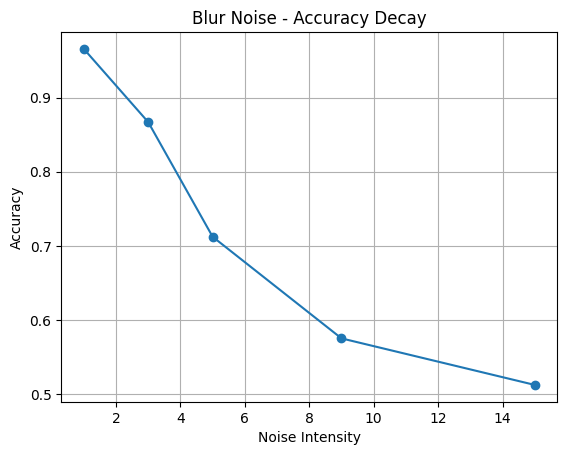

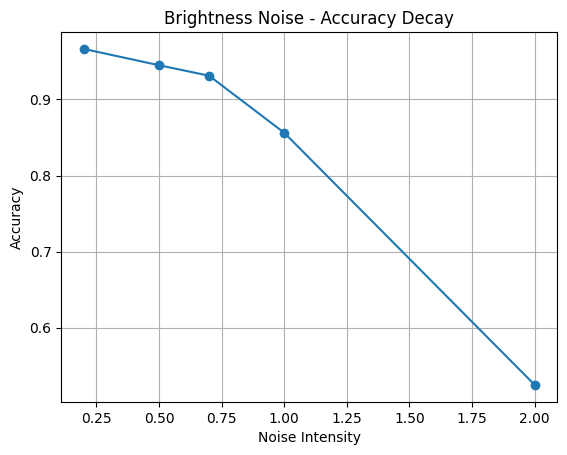

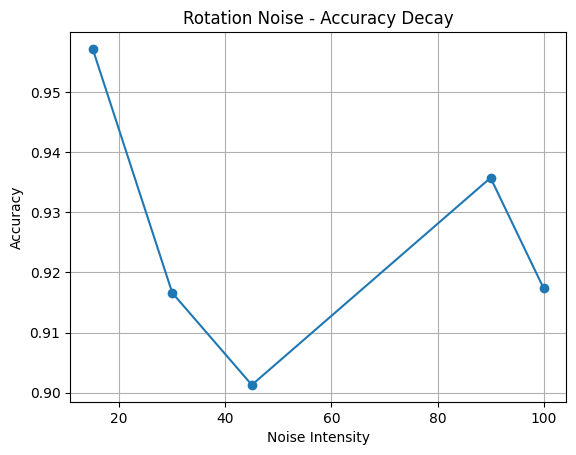

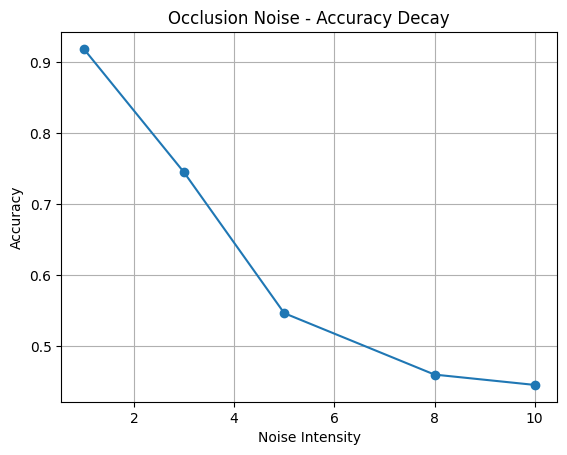

In [ ]:
import matplotlib.pyplot as plt

def plot_noise_curve(noise_type, data):
    intensities = sorted(data.keys())
    accuracies = [data[i]["accuracy"] for i in intensities]

    plt.figure()
    plt.plot(intensities, accuracies, marker='o')
    plt.title(f"{noise_type.capitalize()} Noise - Accuracy Decay")
    plt.xlabel("Noise Intensity")
    plt.ylabel("Accuracy")
    plt.grid()
    plt.show()



for noise_type in ["blur", "brightness", "rotation", "occlusion"]:
    if noise_type in results:
        plot_noise_curve(noise_type, results[noise_type])

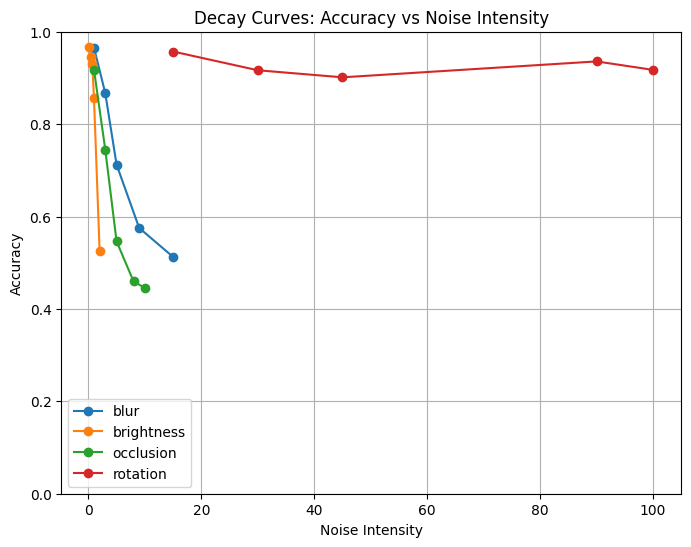

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

for noise_type, intensity_dict in results.items():
    intensities = sorted(intensity_dict.keys())
    accuracies = [intensity_dict[i]["accuracy"] for i in intensities]

    plt.plot(intensities, accuracies, marker='o', label=noise_type)

plt.title("Decay Curves: Accuracy vs Noise Intensity")
plt.xlabel("Noise Intensity")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.grid(True)
plt.legend()

plt.show()

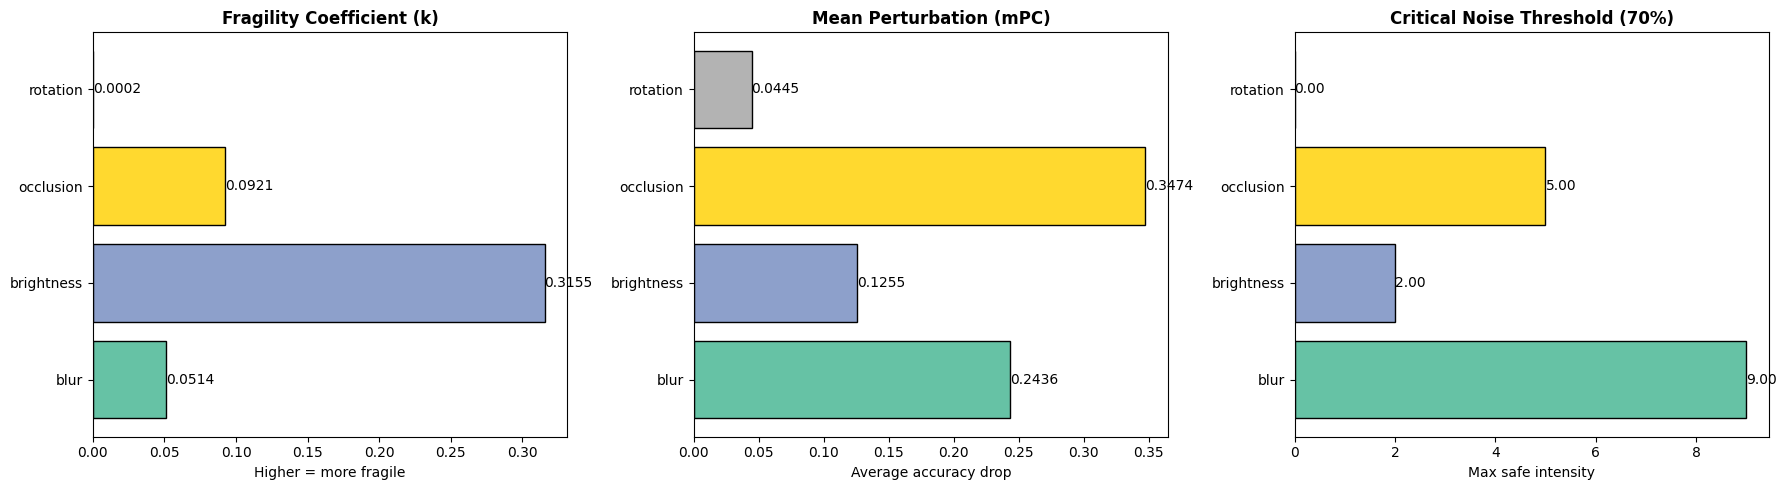

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

noise_keys = list(results.keys())
noise_names = [n.replace("_", " ") for n in noise_keys]

# -----------------------------
# Fragility (k)
# -----------------------------
k_values = [
    decay_params[n]["k"] if decay_params[n]["k"] is not None else 0
    for n in noise_keys
]

# -----------------------------
# mPC
# -----------------------------
mpc_values = [
    mpc[n]
    for n in noise_keys
]

# -----------------------------
# Critical Threshold (70% rule)
# -----------------------------
threshold_values = [
    critical_thresholds[n] if critical_thresholds[n] is not None else 0
    for n in noise_keys
]

# -----------------------------
# Colors
# -----------------------------
colors = plt.cm.Set2(np.linspace(0, 1, len(noise_keys)))

# -----------------------------
# Plot (3 panels)
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ---- 1. Fragility (k) ----
axes[0].barh(noise_names, k_values, color=colors, edgecolor="black")
axes[0].set_title("Fragility Coefficient (k)", fontweight="bold")
axes[0].set_xlabel("Higher = more fragile")

for i, v in enumerate(k_values):
    axes[0].text(v, i, f"{v:.4f}", va="center")

# ---- 2. mPC ----
axes[1].barh(noise_names, mpc_values, color=colors, edgecolor="black")
axes[1].set_title("Mean Perturbation (mPC)", fontweight="bold")
axes[1].set_xlabel("Average accuracy drop")

for i, v in enumerate(mpc_values):
    axes[1].text(v, i, f"{v:.4f}", va="center")

# ---- 3. Critical Threshold ----
axes[2].barh(noise_names, threshold_values, color=colors, edgecolor="black")
axes[2].set_title("Critical Noise Threshold (70%)", fontweight="bold")
axes[2].set_xlabel("Max safe intensity")

for i, v in enumerate(threshold_values):
    axes[2].text(v, i, f"{v:.2f}", va="center")

plt.tight_layout()
plt.savefig("/content/robustness_summary.png", dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
summary = []

for noise in results:
    summary.append({
        "Noise Type": noise,
        "A0 (clean)": f"{decay_params[noise]['A0']:.4f}",
        "k (fragility)": f"{decay_params[noise]['k']:.4f}" if decay_params[noise]["k"] is not None else "N/A",
        "R²": f"{decay_params[noise]['R_squared']:.4f}" if decay_params[noise]["R_squared"] is not None else "N/A",
        "Critical Threshold (Th)": critical_thresholds[noise],
        "mPC": f"{mpc[noise]:.4f}"
    })

df_summary = pd.DataFrame(summary)
print(df_summary)

   Noise Type A0 (clean) k (fragility)      R²  Critical Threshold (Th)  \
0        blur     0.9875        0.0514  0.9376                      9.0   
1  brightness     1.0000        0.2340  0.8186                      2.0   
2   occlusion     0.9779        0.0921  0.9464                      5.0   
3    rotation     0.9339        0.0002  0.0647                      NaN   

      mPC  
0  0.2436  
1  0.1255  
2  0.3474  
3  0.0445  
